# NOVA — Product Embeddings
### Notebook 02: Building the Product Embedding Space

In this notebook we:
1. Load the product feature table from EDA
2. Construct a rich text representation for each product
3. Generate dense vector embeddings using Sentence-Transformers
4. Visualize the embedding space with UMAP
5. Sanity check — do similar products cluster together?
6. Save embeddings for use in the FAISS index (next notebook)

**This is the core of NOVA.** Every recommendation will be driven by these embeddings.

## 0. Imports & Config

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm

from sentence_transformers import SentenceTransformer
import umap
from sklearn.preprocessing import MinMaxScaler

pd.set_option('display.max_columns', None)
sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

DATA_DIR      = Path('../data/processed')
EMBED_DIR     = Path('../data/processed/embeddings')
EMBED_DIR.mkdir(parents=True, exist_ok=True)

print('All imports successful ✅')

All imports successful ✅


## 1. Load Product Features

In [2]:
products = pd.read_csv(DATA_DIR / 'product_features.csv')

print(f'Loaded {len(products):,} products')
print(f'Columns: {list(products.columns)}')
products.head(3)

Loaded 32,951 products
Columns: ['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_category_name_english', 'category_en', 'times_purchased', 'avg_price', 'min_price', 'max_price', 'review_count', 'avg_score']


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,category_en,times_purchased,avg_price,min_price,max_price,review_count,avg_score
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery,perfumery,1,10.91,10.91,10.91,1.0,5.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art,art,1,248.00,248.00,248.00,1.0,5.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure,sports_leisure,1,79.80,79.80,79.80,1.0,5.0


In [3]:
# Keep only products with a known category — we need at least this for text embedding
products = products[products['category_en'].notna()].copy()
products = products.reset_index(drop=True)

print(f'Products with known category: {len(products):,}')

Products with known category: 32,341


## 2. Build Text Representations

Olist doesn't include product titles or descriptions — only category names and physical attributes.

We solve this by constructing a **structured natural language string** for each product that combines:
- Category name
- Price tier (budget / mid-range / premium)
- Size tier (small / medium / large) based on weight
- Number of photos

This gives Sentence-Transformers enough semantic signal to produce meaningful embeddings.

In [4]:
def get_price_tier(price):
    if pd.isna(price):
        return 'unknown price'
    elif price < 50:
        return 'budget'
    elif price < 200:
        return 'mid-range'
    else:
        return 'premium'

def get_size_tier(weight_g):
    if pd.isna(weight_g):
        return 'unknown size'
    elif weight_g < 500:
        return 'small'
    elif weight_g < 5000:
        return 'medium'
    else:
        return 'large'

def build_product_text(row):
    category  = str(row['category_en']).replace('_', ' ')
    price_tier = get_price_tier(row.get('avg_price'))
    size_tier  = get_size_tier(row.get('product_weight_g'))
    photos     = int(row['product_photos_qty']) if pd.notna(row.get('product_photos_qty')) else 1
    photo_str  = 'multiple photos' if photos > 1 else 'single photo'

    return f"{category} product, {price_tier} price range, {size_tier} item, {photo_str}"

products['product_text'] = products.apply(build_product_text, axis=1)

print('Sample product text representations:')
print()
for i, row in products.head(8).iterrows():
    print(f'  [{row["category_en"]}] → "{row["product_text"]}"')

Sample product text representations:

  [perfumery] → "perfumery product, budget price range, small item, single photo"
  [art] → "art product, premium price range, medium item, single photo"
  [sports_leisure] → "sports leisure product, mid-range price range, small item, single photo"
  [baby] → "baby product, mid-range price range, small item, single photo"
  [housewares] → "housewares product, budget price range, medium item, multiple photos"
  [musical_instruments] → "musical instruments product, budget price range, small item, single photo"
  [cool_stuff] → "cool stuff product, premium price range, large item, multiple photos"
  [furniture_decor] → "furniture decor product, budget price range, medium item, multiple photos"


## 3. Generate Embeddings with Sentence-Transformers

We use `all-MiniLM-L6-v2` — a fast, lightweight model that produces 384-dimensional embeddings. It's a great default for semantic similarity tasks and runs well on CPU.

In [5]:
MODEL_NAME = 'all-MiniLM-L6-v2'

print(f'Loading model: {MODEL_NAME}')
model = SentenceTransformer(MODEL_NAME)
print(f'Model loaded ✅')
print(f'Embedding dimension: {model.get_sentence_embedding_dimension()}')

Loading model: all-MiniLM-L6-v2


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded ✅
Embedding dimension: 384


In [6]:
texts = products['product_text'].tolist()

print(f'Generating embeddings for {len(texts):,} products...')
print('This will take a few minutes on CPU.\n')

embeddings = model.encode(
    texts,
    batch_size=256,
    show_progress_bar=True,
    normalize_embeddings=True   # L2 normalize — cosine similarity becomes dot product
)

print(f'\nEmbeddings shape: {embeddings.shape}')
print(f'Each product is now a {embeddings.shape[1]}-dimensional vector ✅')

Generating embeddings for 32,341 products...
This will take a few minutes on CPU.



Batches:   0%|          | 0/127 [00:00<?, ?it/s]


Embeddings shape: (32341, 384)
Each product is now a 384-dimensional vector ✅


In [7]:
# Quick sanity check on the embedding values
print('Embedding stats:')
print(f'  Mean: {embeddings.mean():.4f}')
print(f'  Std:  {embeddings.std():.4f}')
print(f'  Min:  {embeddings.min():.4f}')
print(f'  Max:  {embeddings.max():.4f}')
print()

# Verify L2 norms are ~1 (because normalize_embeddings=True)
norms = np.linalg.norm(embeddings, axis=1)
print(f'  L2 norm mean: {norms.mean():.4f} (should be ~1.0)')

Embedding stats:
  Mean: 0.0002
  Std:  0.0510
  Min:  -0.2064
  Max:  0.2040

  L2 norm mean: 1.0000 (should be ~1.0)


## 4. Sanity Check — Similarity Between Products

Before visualizing, let's verify the embeddings make intuitive sense. We pick a few query products and find their nearest neighbors using cosine similarity.

In [8]:
def find_similar_products(query_idx, embeddings, products, top_k=5):
    query_vec = embeddings[query_idx]
    # Dot product = cosine similarity (since embeddings are L2-normalized)
    scores = embeddings @ query_vec
    top_indices = np.argsort(scores)[::-1][1:top_k+1]  # exclude self

    query_product = products.iloc[query_idx]
    print(f'Query: "{query_product["product_text"]}"')
    print(f'Category: {query_product["category_en"]}')
    print()
    print('Most similar products:')
    for rank, idx in enumerate(top_indices, 1):
        sim = scores[idx]
        p = products.iloc[idx]
        print(f'  {rank}. [{p["category_en"]}] "{p["product_text"]}"  (similarity: {sim:.4f})')
    print()

In [9]:
# Try a few different product categories
categories_to_test = ['computers_accessories', 'bed_bath_table', 'sports_leisure', 'health_beauty']

for cat in categories_to_test:
    cat_products = products[products['category_en'] == cat]
    if len(cat_products) > 0:
        idx = cat_products.index[0]
        find_similar_products(idx, embeddings, products)
        print('-' * 70)

Query: "computers accessories product, mid-range price range, medium item, single photo"
Category: computers_accessories

Most similar products:
  1. [computers_accessories] "computers accessories product, mid-range price range, medium item, single photo"  (similarity: 1.0000)
  2. [computers_accessories] "computers accessories product, mid-range price range, medium item, single photo"  (similarity: 1.0000)
  3. [computers_accessories] "computers accessories product, mid-range price range, medium item, single photo"  (similarity: 1.0000)
  4. [computers_accessories] "computers accessories product, mid-range price range, medium item, single photo"  (similarity: 1.0000)
  5. [computers_accessories] "computers accessories product, mid-range price range, medium item, single photo"  (similarity: 1.0000)

----------------------------------------------------------------------
Query: "bed bath table product, mid-range price range, medium item, single photo"
Category: bed_bath_table

Most simil

## 5. Visualize the Embedding Space with UMAP

UMAP reduces 384 dimensions down to 2 so we can visually inspect whether similar products cluster together. Good embeddings should show clear category clusters.

In [10]:
# UMAP on a sample for speed (full dataset takes a while)
SAMPLE_SIZE = 5000

sample_idx = np.random.choice(len(products), size=min(SAMPLE_SIZE, len(products)), replace=False)
sample_embeddings = embeddings[sample_idx]
sample_products   = products.iloc[sample_idx].reset_index(drop=True)

print(f'Running UMAP on {len(sample_idx):,} products...')

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric='cosine',
    random_state=42
)

umap_embeddings = reducer.fit_transform(sample_embeddings)
print(f'UMAP complete ✅  Shape: {umap_embeddings.shape}')

Running UMAP on 5,000 products...


/opt/anaconda3/envs/ml/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/ml/lib/python3.11/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/opt/anaconda3/envs/ml/lib/python3.11/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


UMAP complete ✅  Shape: (5000, 2)


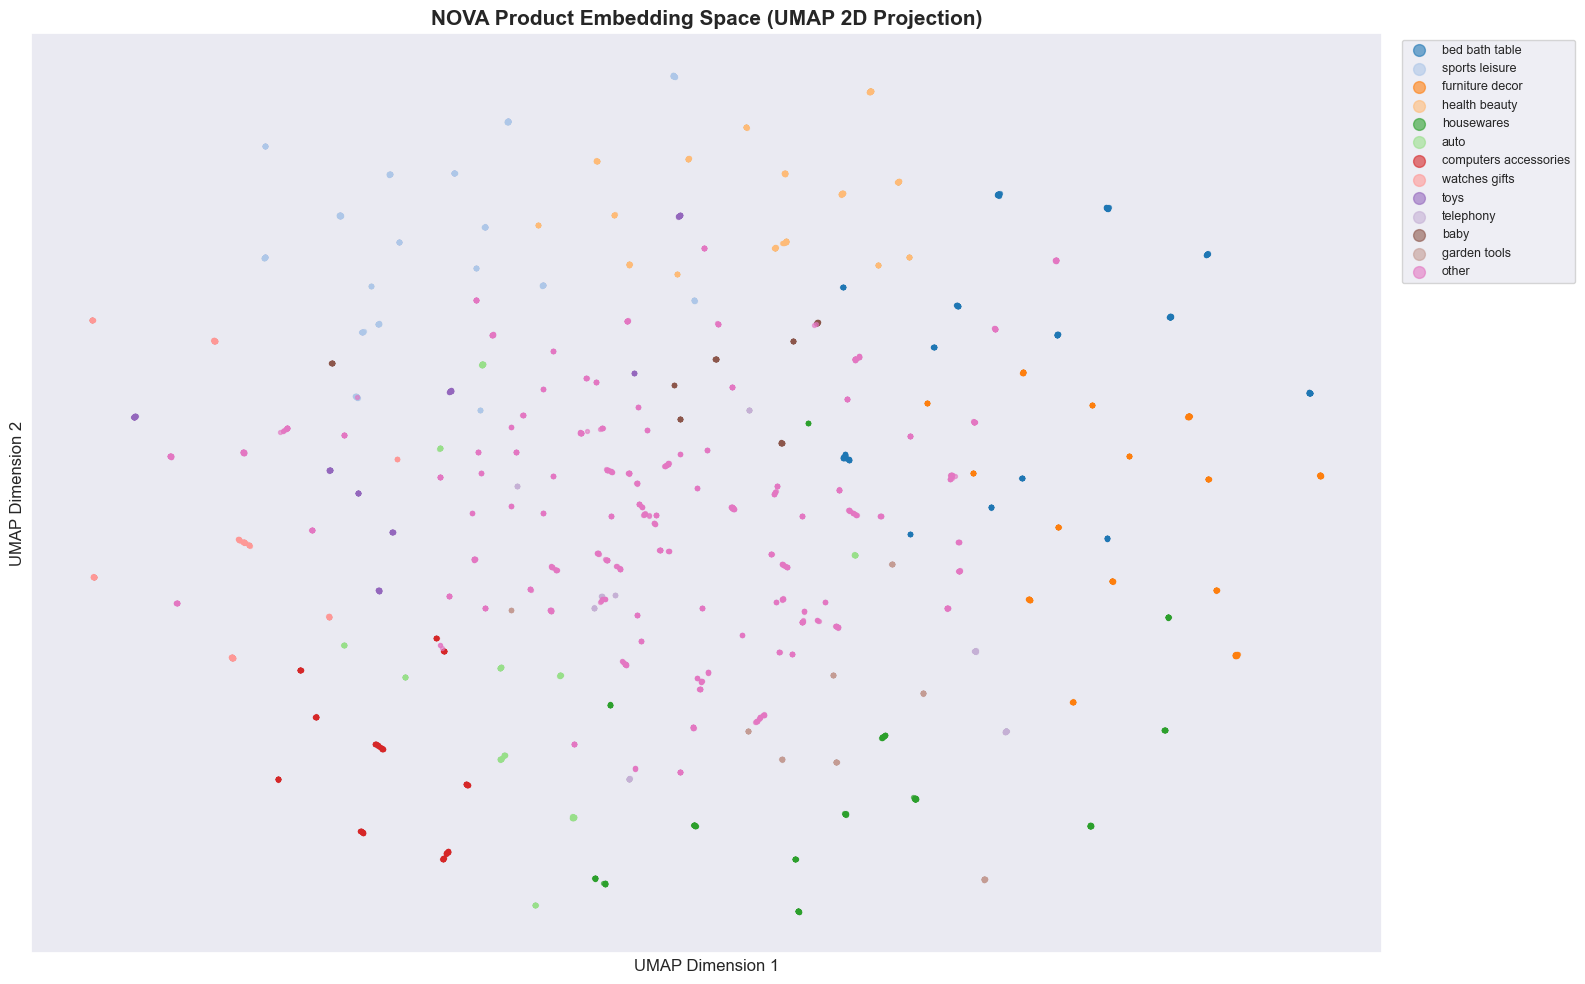

UMAP plot saved ✅


In [11]:
# Plot — color by top categories
top_cats = sample_products['category_en'].value_counts().head(12).index.tolist()
sample_products['plot_category'] = sample_products['category_en'].apply(
    lambda x: x if x in top_cats else 'other'
)

palette = sns.color_palette('tab20', n_colors=len(top_cats) + 1)
cat_to_color = {cat: palette[i] for i, cat in enumerate(top_cats + ['other'])}

fig, ax = plt.subplots(figsize=(16, 10))

for cat in top_cats + ['other']:
    mask = sample_products['plot_category'] == cat
    ax.scatter(
        umap_embeddings[mask, 0],
        umap_embeddings[mask, 1],
        c=[cat_to_color[cat]],
        label=cat.replace('_', ' '),
        s=8,
        alpha=0.6
    )

ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9, markerscale=3)
ax.set_title('NOVA Product Embedding Space (UMAP 2D Projection)', fontsize=15, fontweight='bold')
ax.set_xlabel('UMAP Dimension 1')
ax.set_ylabel('UMAP Dimension 2')
ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
plt.savefig(DATA_DIR / 'embeddings/umap_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

print('UMAP plot saved ✅')

## 6. Category Centroid Analysis

Compute the average embedding per category — the "centroid" of each category cluster. This will later be used to generate cold-start user vectors based on what category they landed on.

In [12]:
# Compute category centroids
category_centroids = {}

for cat in products['category_en'].unique():
    mask = products['category_en'] == cat
    cat_embeddings = embeddings[mask.values]
    centroid = cat_embeddings.mean(axis=0)
    centroid = centroid / np.linalg.norm(centroid)  # normalize
    category_centroids[cat] = centroid

print(f'Computed centroids for {len(category_centroids)} categories ✅')
print()

# Example: most similar categories to 'computers_accessories'
if 'computers_accessories' in category_centroids:
    query_cat = 'computers_accessories'
    query_centroid = category_centroids[query_cat]
    
    scores = {
        cat: float(np.dot(query_centroid, centroid))
        for cat, centroid in category_centroids.items()
        if cat != query_cat
    }
    top_similar = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:5]
    
    print(f'Categories most similar to "{query_cat}":')
    for cat, score in top_similar:
        print(f'  {cat:<45} similarity: {score:.4f}')

Computed centroids for 73 categories ✅

Categories most similar to "computers_accessories":
  computers                                     similarity: 0.9095
  electronics                                   similarity: 0.8646
  pc_gamer                                      similarity: 0.7997
  cool_stuff                                    similarity: 0.7857
  luggage_accessories                           similarity: 0.7811


## 7. Save Everything

In [13]:
# Save product embeddings
embeddings_path = EMBED_DIR / 'product_embeddings.npy'
np.save(embeddings_path, embeddings)
print(f'Product embeddings saved → {embeddings_path} ✅')
print(f'Shape: {embeddings.shape}')

# Save product IDs (to map embedding index → product_id)
product_ids_path = EMBED_DIR / 'product_ids.npy'
np.save(product_ids_path, products['product_id'].values)
print(f'Product IDs saved       → {product_ids_path} ✅')

# Save product text representations
products[['product_id', 'category_en', 'product_text', 'avg_price', 'product_weight_g']].to_csv(
    EMBED_DIR / 'product_metadata.csv', index=False
)
print(f'Product metadata saved  → {EMBED_DIR}/product_metadata.csv ✅')

# Save category centroids
centroids_df = pd.DataFrame(
    {cat: vec for cat, vec in category_centroids.items()}
).T
centroids_df.index.name = 'category'
centroids_df.to_csv(EMBED_DIR / 'category_centroids.csv')
print(f'Category centroids saved → {EMBED_DIR}/category_centroids.csv ✅')

Product embeddings saved → ../data/processed/embeddings/product_embeddings.npy ✅
Shape: (32341, 384)
Product IDs saved       → ../data/processed/embeddings/product_ids.npy ✅
Product metadata saved  → ../data/processed/embeddings/product_metadata.csv ✅
Category centroids saved → ../data/processed/embeddings/category_centroids.csv ✅


In [15]:
# Final summary
print('-' * 55)
print('  NOTEBOOK 02 COMPLETE')
print('-' * 55)
print()
print(f'  Products embedded:     {len(products):,}')
print(f'  Embedding dimensions:  {embeddings.shape[1]}')
print(f'  Categories covered:    {len(category_centroids)}')
print()
print('  Files saved to data/processed/embeddings/:')
print('    - product_embeddings.npy')
print('    - product_ids.npy')
print('    - product_metadata.csv')
print('    - category_centroids.csv')
print('    - umap_visualization.png')
print()
print('  Next: 03_faiss_index.ipynb')
print('  Build the FAISS index and run first real recommendations')

-------------------------------------------------------
  NOTEBOOK 02 COMPLETE
-------------------------------------------------------

  Products embedded:     32,341
  Embedding dimensions:  384
  Categories covered:    73

  Files saved to data/processed/embeddings/:
    - product_embeddings.npy
    - product_ids.npy
    - product_metadata.csv
    - category_centroids.csv
    - umap_visualization.png

  Next: 03_faiss_index.ipynb
  Build the FAISS index and run first real recommendations


## Summary

**What we built:**
- A structured text representation for every product in the Olist catalog using category, price tier, and size tier
- Dense 384-dimensional embeddings using `all-MiniLM-L6-v2`
- A UMAP visualization confirming that similar products cluster together in embedding space
- Category centroids that can serve as starting user vectors for cold-start inference

**Key insight:** Even without product titles or descriptions, the combination of category + price tier + size tier produces embeddings with meaningful semantic structure. Products in the same category cluster together, and related categories (e.g. `computers_accessories` and `electronics`) appear nearby in the embedding space.

**Next notebook:** `03_faiss_index.ipynb`
Load the saved embeddings, build a FAISS index, and run the first real end-to-end recommendations.